# SGIE ROBUSTO V2

Execução com dados Open-Meteo e Huawei, agosto/2024 a março/2025. Emissão operacional às 21h; zeros excluídos. Extraia o ZIP completo.

As células desta entrega foram executadas em processo IPython local. O treinamento real foi executado pelo script executar.py; as saídas abaixo leem os resultados auditados.

In [1]:
from pathlib import Path
import json, subprocess, sys
import pandas as pd
from IPython.display import display
import sgie_pipeline as p
c = p.read_config()
R = p.BASE / 'resultados' / c['run_id']
EXECUTAR_TREINAMENTO = False
if EXECUTAR_TREINAMENTO:
    subprocess.run([sys.executable, 'executar.py', '--workers', '6'], check=True)
assert json.loads((R/'assinatura.json').read_text()) == p.signature()
print(json.loads((R/'auditoria_final.json').read_text()))

{'status': 'aprovado', 'modelos_verificados': 80, 'horas': 5832, 'amostras_ajuste': 2816, 'amostras_metricas': 2750, 'baseline_apos_emissao_nas_metricas': 0, 'candidatos_invalidados': 0, 'avisos_buscas_todas_tentativas': 1, 'repeticoes_orcamento_busca': 1, 'total_ajustes_reais': 13041, 'selecionados_convergentes_todos_folds': True, 'nota': 'ICs exploratorios condicionais; estabilidade de reajuste com parametros fixos; teste cronologico nao e novo conjunto intocado.'}


In [2]:
display(pd.read_csv(R/'cobertura_mensal.csv'))
display(pd.read_csv(R/'metricas_lomo_agrupadas.csv'))
display(pd.read_csv(R/'metricas_lomo_mensais.csv'))

,mes,horas,ajuste,metricas,positivos_excluidos_solar
0,2024-08,744,303,298,34
1,2024-09,720,298,277,35
2,2024-10,744,362,354,37
3,2024-11,720,376,369,25
4,2024-12,744,411,400,36
5,2025-01,744,390,383,36
6,2025-02,672,335,331,26
7,2025-03,744,341,338,40


,modelo,n,RMSE_kWh,MAE_kWh,R2,MBE_kWh,Pearson,nRMSE_media_pct,nMAE_media_pct,nRMSE_capacidade_pct,nMAE_capacidade_pct,nMBE_pct,Skill_pct,energia_medida_recorte_kWh,energia_prevista_recorte_kWh,RMSE_persistencia_kWh
0,KRR,2750,1.338358,1.106049,0.635167,-0.013807,0.797057,40.668397,33.609272,13.383585,11.060494,-0.419542,21.723056,9049.99,9012.021490,1.709774
1,MLP,2750,1.349393,1.115259,0.629127,-0.019391,0.793586,41.003693,33.889116,13.493928,11.152588,-0.589243,21.077691,9049.99,8996.663524,1.709774
2,SVR,2750,1.333209,1.115247,0.637969,0.023200,0.799150,40.511916,33.888757,13.332088,11.152469,0.704975,22.024245,9049.99,9113.790198,1.709774
3,XGBoost,2750,1.361953,1.138413,0.622190,-0.015156,0.788950,41.385347,34.592685,13.619526,11.384126,-0.460542,20.343100,9049.99,9008.310958,1.709774
4,Persistencia24h,2750,1.709774,1.180284,0.404576,-0.002778,0.702392,51.954503,35.865012,17.097736,11.802836,-0.084420,0.000000,9049.99,9042.350000,1.709774


,mes,modelo,n,RMSE_kWh,MAE_kWh,R2,MBE_kWh,Pearson,nRMSE_media_pct,nMAE_media_pct,nRMSE_capacidade_pct,nMAE_capacidade_pct,nMBE_pct,Skill_pct,energia_medida_recorte_kWh,energia_prevista_recorte_kWh,RMSE_persistencia_kWh
0,2024-08,KRR,298,1.201698,1.010989,0.405356,0.674487,0.770254,68.412649,57.555571,12.016980,10.109887,38.398511,4.322202,523.45,724.447008,1.255984
1,2024-08,MLP,298,1.180578,1.001033,0.426074,0.641778,0.771912,67.210309,56.988806,11.805784,10.010332,36.536388,6.003723,523.45,714.699725,1.255984
2,2024-08,SVR,298,1.142663,0.959038,0.462347,0.441533,0.736879,65.051771,54.598036,11.426627,9.590383,25.136447,9.022523,523.45,655.026734,1.255984
3,2024-08,XGBoost,298,1.143821,0.973832,0.461256,0.443638,0.736996,65.117725,55.440243,11.438212,9.738321,25.256279,8.930284,523.45,655.653991,1.255984
4,2024-09,KRR,277,1.278953,1.082752,0.546786,0.483560,0.783468,54.547547,46.179538,12.789529,10.827518,20.623901,33.295483,649.47,783.416051,1.917341
5,2024-09,MLP,277,1.283971,1.071176,0.543223,0.392038,0.773841,54.761583,45.685814,12.839713,10.711757,16.720463,33.033745,649.47,758.064391,1.917341
6,2024-09,SVR,277,1.266478,1.071088,0.555584,0.503832,0.792214,54.015487,45.682054,12.664779,10.710875,21.488513,33.946123,649.47,789.031446,1.917341
7,2024-09,XGBoost,277,1.276088,1.083037,0.548814,0.393502,0.771449,54.425373,46.191717,12.760883,10.830373,16.782910,33.444887,649.47,758.469967,1.917341
8,2024-10,KRR,354,1.202882,0.991725,0.664858,0.150014,0.819672,38.742261,31.941366,12.028815,9.917253,4.831644,28.781305,1099.11,1152.215083,1.688997
9,2024-10,MLP,354,1.253299,1.022787,0.636175,0.159472,0.802885,40.366102,32.941798,12.532990,10.227870,5.136262,25.796249,1099.11,1155.563169,1.688997


In [3]:
display(pd.read_csv(R/'metricas_cronologicas.csv'))
display(pd.read_csv(R/'estabilidade_lomo.csv'))
display(pd.read_csv(R/'incerteza_pareada.csv'))
if (R/'comparacao_v1_v2.csv').exists():
    display(pd.read_csv(R/'comparacao_v1_v2.csv'))

,modelo,n,RMSE_kWh,MAE_kWh,R2,MBE_kWh,Pearson,nRMSE_media_pct,nMAE_media_pct,nRMSE_capacidade_pct,nMAE_capacidade_pct,nMBE_pct,Skill_pct,energia_medida_recorte_kWh,energia_prevista_recorte_kWh,RMSE_persistencia_kWh
0,KRR,669,1.332300,1.140625,0.605098,-0.354794,0.795678,35.717061,30.578527,13.322998,11.406248,-9.511517,17.248904,2495.47,2258.112946,1.610009
1,MLP,669,1.311333,1.121181,0.617430,-0.197807,0.791608,35.154964,30.057261,13.113327,11.211808,-5.302932,18.551197,2495.47,2363.136919,1.610009
2,SVR,669,1.327677,1.147190,0.607834,-0.200687,0.786700,35.593135,30.754522,13.276772,11.471896,-5.380142,17.536020,2495.47,2361.210178,1.610009
3,XGBoost,669,1.348220,1.163280,0.595604,-0.272287,0.783318,36.143873,31.185888,13.482205,11.632802,-7.299636,16.260044,2495.47,2313.309767,1.610009
4,Persistencia24h,669,1.610009,1.083587,0.423311,0.051241,0.711040,43.162039,29.049438,16.100086,10.835874,1.373689,0.000000,2495.47,2529.750000,1.610009


,modelo,semente,n,RMSE_kWh,MAE_kWh,R2,MBE_kWh,Pearson,nRMSE_media_pct,nMAE_media_pct,nRMSE_capacidade_pct,nMAE_capacidade_pct,nMBE_pct,Skill_pct,energia_medida_recorte_kWh,energia_prevista_recorte_kWh,RMSE_persistencia_kWh
0,MLP,42,2750,1.349393,1.115259,0.629127,-0.019391,0.793586,41.003693,33.889116,13.493928,11.152588,-0.589243,21.077691,9049.99,8996.663524,1.709774
1,MLP,17,2750,1.354643,1.120629,0.626235,-0.010934,0.791459,41.163226,34.052311,13.546429,11.206293,-0.332256,20.770628,9049.99,9019.920904,1.709774
2,MLP,73,2750,1.349737,1.110948,0.628937,-0.027352,0.793554,41.014166,33.758136,13.497374,11.109483,-0.831141,21.057534,9049.99,8974.771810,1.709774
3,XGBoost,42,2750,1.361953,1.138413,0.622190,-0.015156,0.788950,41.385347,34.592685,13.619526,11.384126,-0.460542,20.343100,9049.99,9008.310958,1.709774
4,XGBoost,17,2750,1.355090,1.132434,0.625988,-0.021962,0.791511,41.176814,34.411003,13.550900,11.324336,-0.667363,20.744476,9049.99,8989.593697,1.709774
5,XGBoost,73,2750,1.360572,1.136982,0.622956,-0.018295,0.789558,41.343401,34.549227,13.605722,11.369824,-0.555928,20.423836,9049.99,8999.678572,1.709774


,modelo_A,modelo_B,diferenca_RMSE_A_menos_B,IC95_inferior,IC95_superior,bloco_dias,replicacoes,interpretacao
0,KRR,MLP,-0.011034,-0.023322,0.001203,7,2000,exploratorio_condicional_sem_correcao_multipla...
1,KRR,SVR,0.005150,-0.004705,0.015515,7,2000,exploratorio_condicional_sem_correcao_multipla...
2,KRR,XGBoost,-0.023594,-0.040371,-0.005777,7,2000,exploratorio_condicional_sem_correcao_multipla...
3,MLP,SVR,0.016184,0.004736,0.027788,7,2000,exploratorio_condicional_sem_correcao_multipla...
4,MLP,XGBoost,-0.012560,-0.031763,0.006586,7,2000,exploratorio_condicional_sem_correcao_multipla...
5,SVR,XGBoost,-0.028744,-0.041532,-0.015855,7,2000,exploratorio_condicional_sem_correcao_multipla...


,modelo,RMSE_kWh_v1,RMSE_kWh_v2,RMSE_kWh_delta,MAE_kWh_v1,MAE_kWh_v2,MAE_kWh_delta,R2_v1,R2_v2,R2_delta
0,KRR,1.340524,1.338358,-0.002166,1.113444,1.106049,-0.007394,0.633986,0.635167,0.001182
1,MLP,1.338015,1.349393,0.011378,1.103315,1.115259,0.011943,0.635355,0.629127,-0.006228
2,SVR,1.342065,1.333209,-0.008856,1.109026,1.115247,0.006221,0.633144,0.637969,0.004825
3,XGBoost,1.383907,1.361953,-0.021954,1.128346,1.138413,0.010067,0.609912,0.622190,0.012279
4,Persistencia24h,1.709774,1.709774,0.000000,1.180284,1.180284,0.000000,0.404576,0.404576,0.000000


In [4]:
for nome in c['candidatos']:
    f = R/'FINAL'/nome
    d = json.loads((f/'concluido.json').read_text())
    print(nome, d['parametros'], 'RMSE de seleção interna:', d['RMSE_validacao'])
    display(pd.read_csv(f/'metricas_externas.csv'))

KRR {'alpha': 2.568386730418734, 'coef0': 1.0, 'degree': 3, 'gamma': 0.05718030235668149, 'kernel': 'polynomial'} RMSE de seleção interna: 1.449289187084718
MLP {'hidden_layer_sizes': [5, 5], 'alpha': 0.1, 'learning_rate_init': 0.001, 'batch_size': 'auto', 'activation': 'relu'} RMSE de seleção interna: 1.4266145278629452
SVR {'C': 34.82675727581821, 'epsilon': 0.6973941757037488, 'gamma': 0.015062483652633225, 'kernel': 'rbf'} RMSE de seleção interna: 1.4313388065388553
XGBoost {'colsample_bytree': 0.85, 'learning_rate': 0.031950211734973935, 'max_depth': 3, 'min_child_weight': 16, 'n_estimators': 200, 'reg_alpha': 1.0, 'reg_lambda': 0.849051908330512, 'subsample': 0.7} RMSE de seleção interna: 1.4685376875023841


,papel,n,RMSE_kWh,MAE_kWh,R2,MBE_kWh,Pearson,nRMSE_media_pct,nMAE_media_pct,nRMSE_capacidade_pct,nMAE_capacidade_pct,nMBE_pct,Skill_pct,energia_medida_recorte_kWh,energia_prevista_recorte_kWh,RMSE_persistencia_kWh,n_limitadas,RMSE_bruta_kWh
0,treino_reajuste,2750,1.309332,1.079147,0.65082,-0.020668,0.806795,39.78639,32.791798,13.093325,10.791471,-0.628027,23.420709,9049.99,8993.153615,1.709774,0,1.309332


,papel,n,RMSE_kWh,MAE_kWh,R2,MBE_kWh,Pearson,nRMSE_media_pct,nMAE_media_pct,nRMSE_capacidade_pct,nMAE_capacidade_pct,nMBE_pct,Skill_pct,energia_medida_recorte_kWh,energia_prevista_recorte_kWh,RMSE_persistencia_kWh,n_limitadas,RMSE_bruta_kWh
0,treino_reajuste,2750,1.306944,1.077948,0.652093,-0.022882,0.807592,39.713821,32.755349,13.069443,10.779476,-0.695301,23.560386,9049.99,8987.065325,1.709774,0,1.306944


,papel,n,RMSE_kWh,MAE_kWh,R2,MBE_kWh,Pearson,nRMSE_media_pct,nMAE_media_pct,nRMSE_capacidade_pct,nMAE_capacidade_pct,nMBE_pct,Skill_pct,energia_medida_recorte_kWh,energia_prevista_recorte_kWh,RMSE_persistencia_kWh,n_limitadas,RMSE_bruta_kWh
0,treino_reajuste,2750,1.319717,1.106678,0.645259,0.040961,0.804399,40.101955,33.628359,13.197174,11.066775,1.244671,22.813321,9049.99,9162.63258,1.709774,0,1.319717


,papel,n,RMSE_kWh,MAE_kWh,R2,MBE_kWh,Pearson,nRMSE_media_pct,nMAE_media_pct,nRMSE_capacidade_pct,nMAE_capacidade_pct,nMBE_pct,Skill_pct,energia_medida_recorte_kWh,energia_prevista_recorte_kWh,RMSE_persistencia_kWh,n_limitadas,RMSE_bruta_kWh
0,treino_reajuste,2750,1.251727,1.031796,0.68087,-0.021906,0.825657,38.035951,31.352953,12.517272,10.317961,-0.665644,26.789886,9049.99,8989.749248,1.709774,0,1.251727


O teste cronológico é exploratório, com meteorologia histórica. A estabilidade mede reajustes com parâmetros fixos. Os ICs são condicionais às previsões. Consulte PROTOCOLO.md antes de usar resultados no artigo.

## Gráficos por modelo e por dia

Previsões de teste LOMO, não previsões dos modelos finais sobre o próprio treino. Os horários excluídos ficam como lacunas. As somas diárias abrangem somente os horários elegíveis. LOMO e meteorologia histórica não comprovam desempenho operacional day-ahead.

In [5]:
from pathlib import Path
import subprocess, sys
from IPython.display import Image, display
BASE = Path.cwd()
assert (BASE/'plotar_resultados.py').exists(), 'Abra o notebook na pasta do pipeline.'
if not (BASE/'graficos/auditoria_graficos.json').exists():
    subprocess.run([sys.executable, str(BASE/'plotar_resultados.py'), '--todos-dias'], check=True)
print('Gráficos disponíveis para KRR, MLP, SVR e XGBoost.')

Gráficos disponíveis para KRR, MLP, SVR e XGBoost.


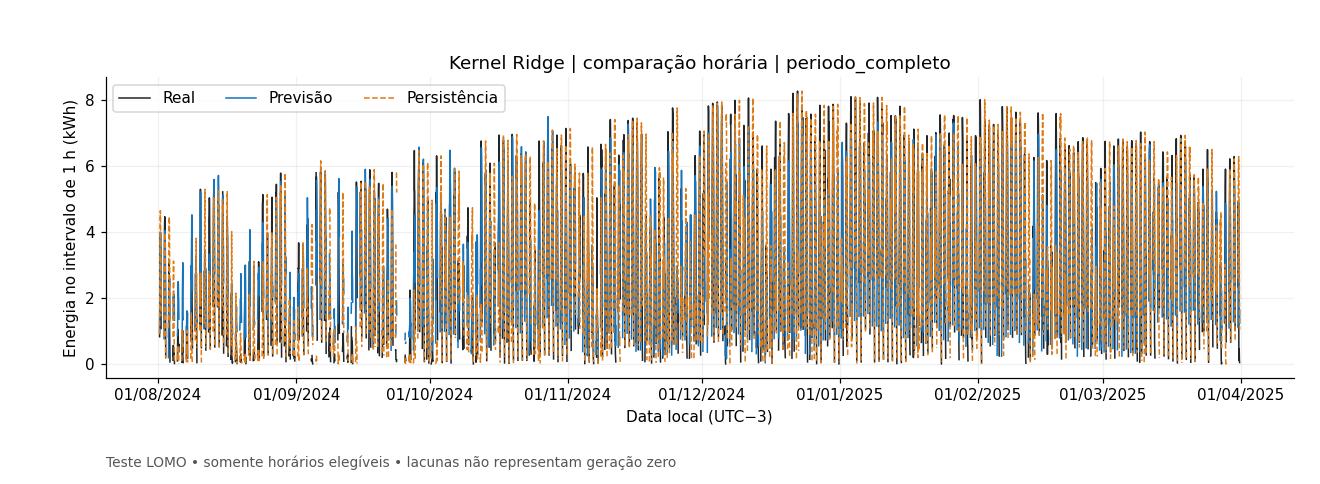

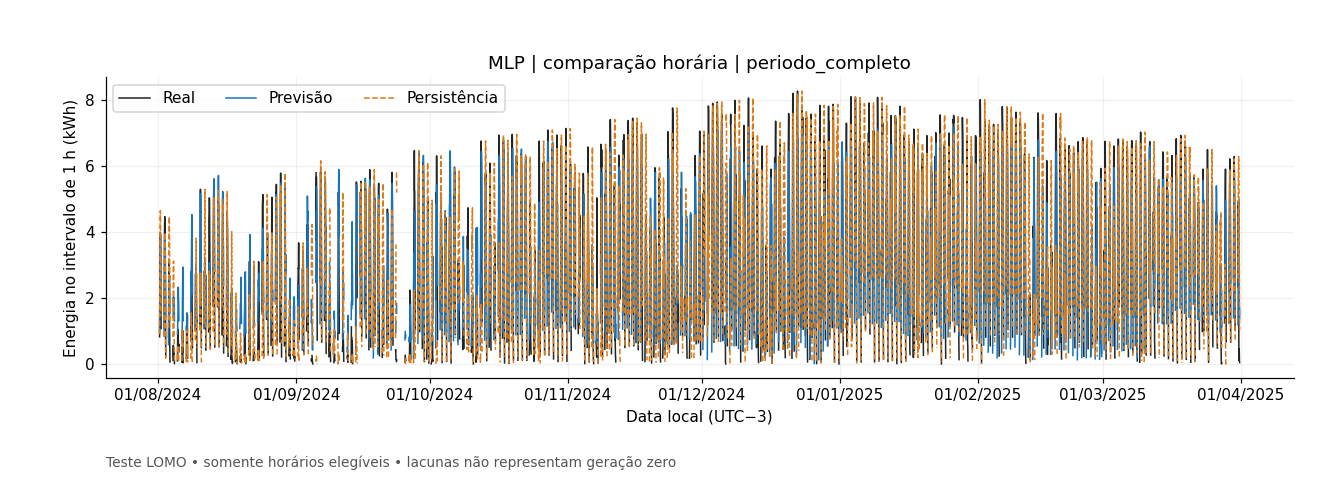

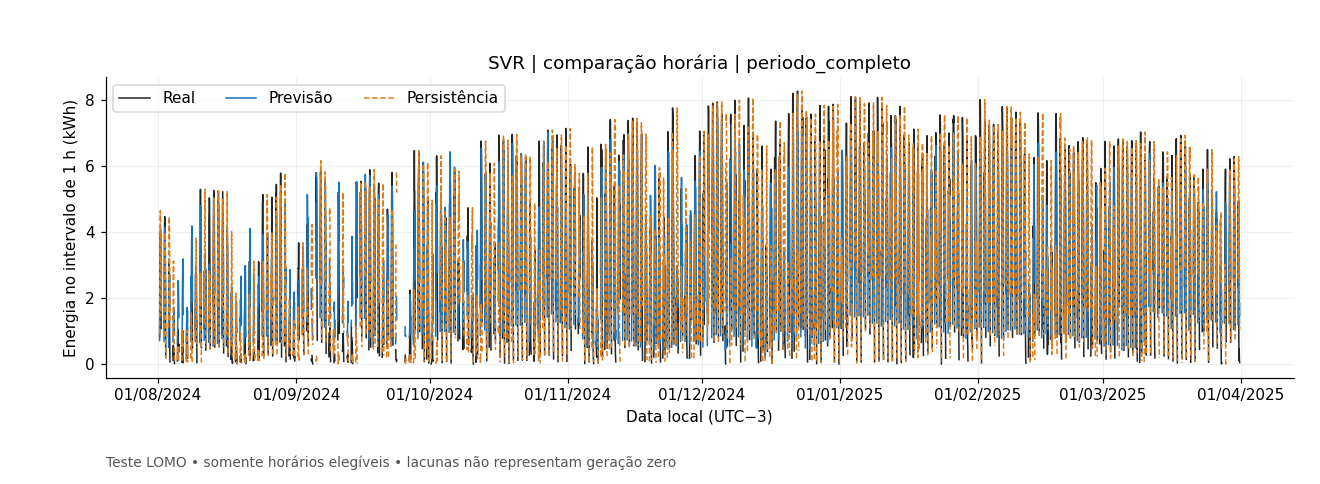

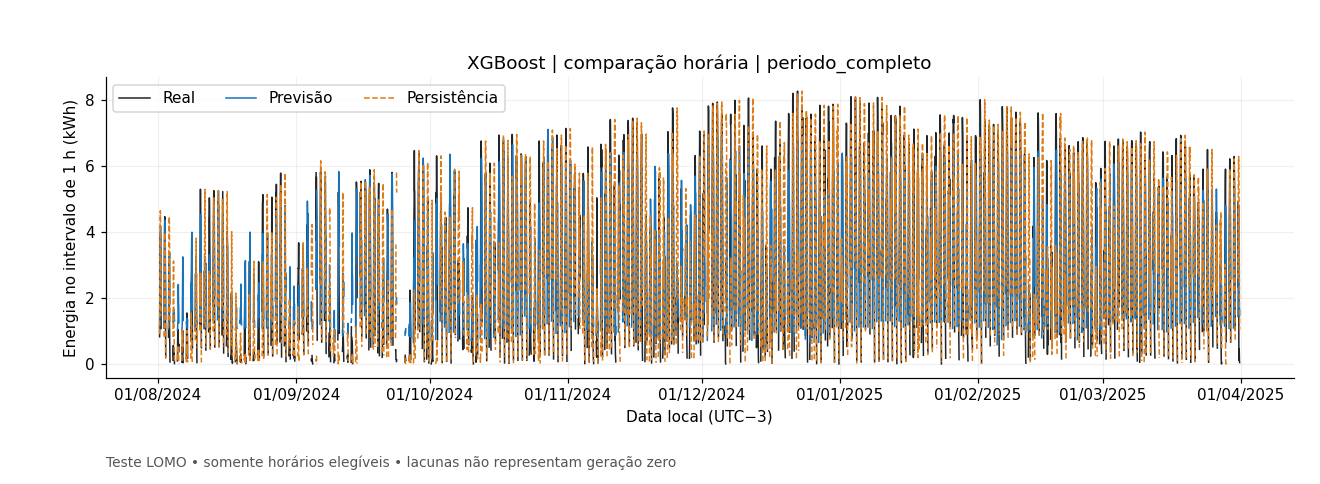

In [6]:
for modelo in ['KRR', 'MLP', 'SVR', 'XGBoost']:
    display(Image(filename=str(BASE/'graficos/horarios'/f'{modelo}_periodo_completo.png')))

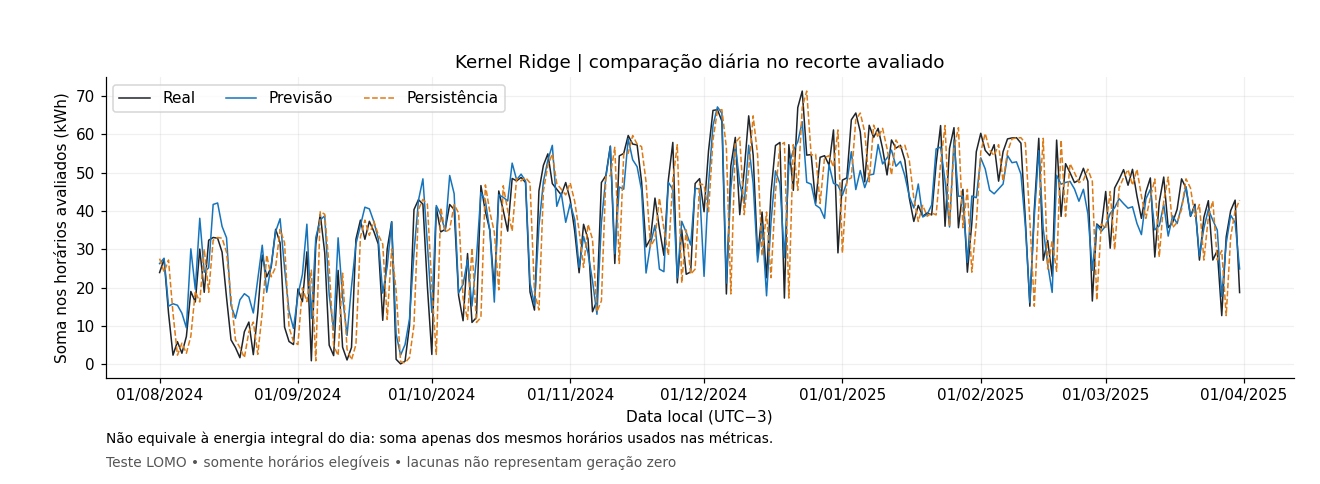

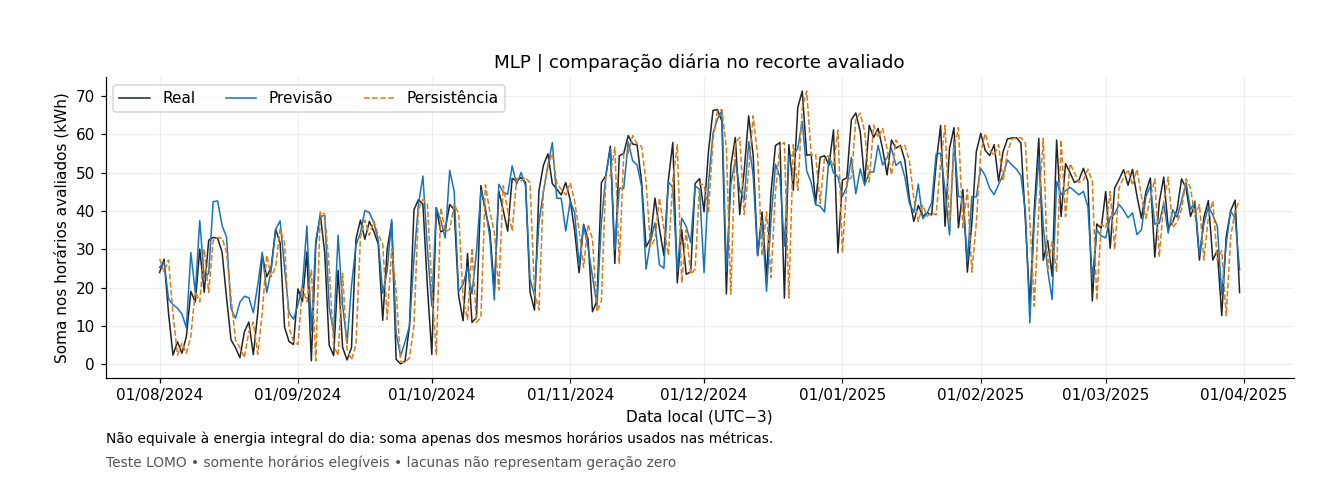

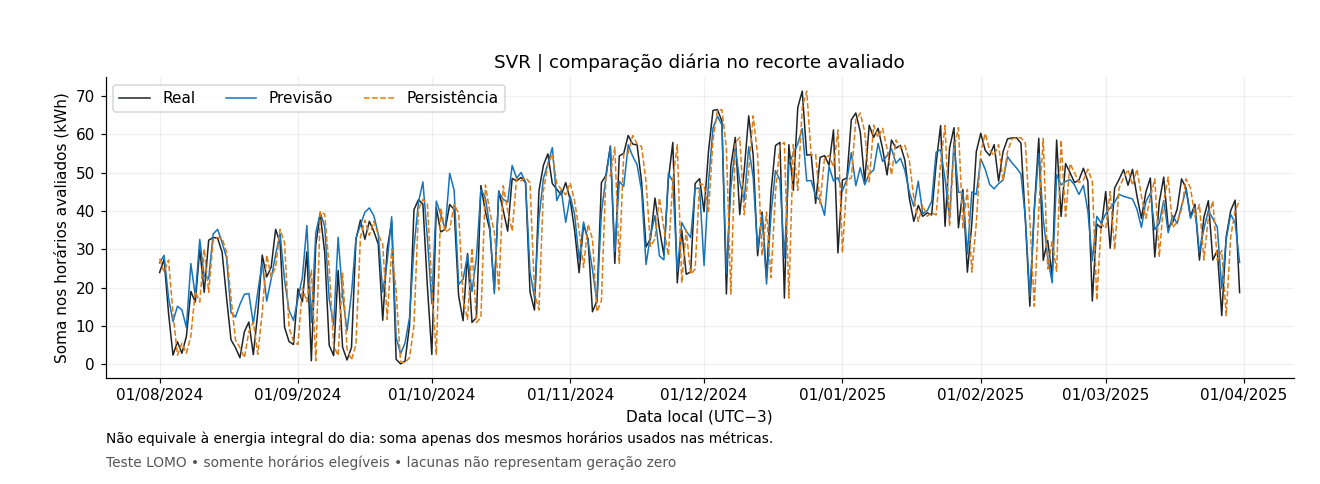

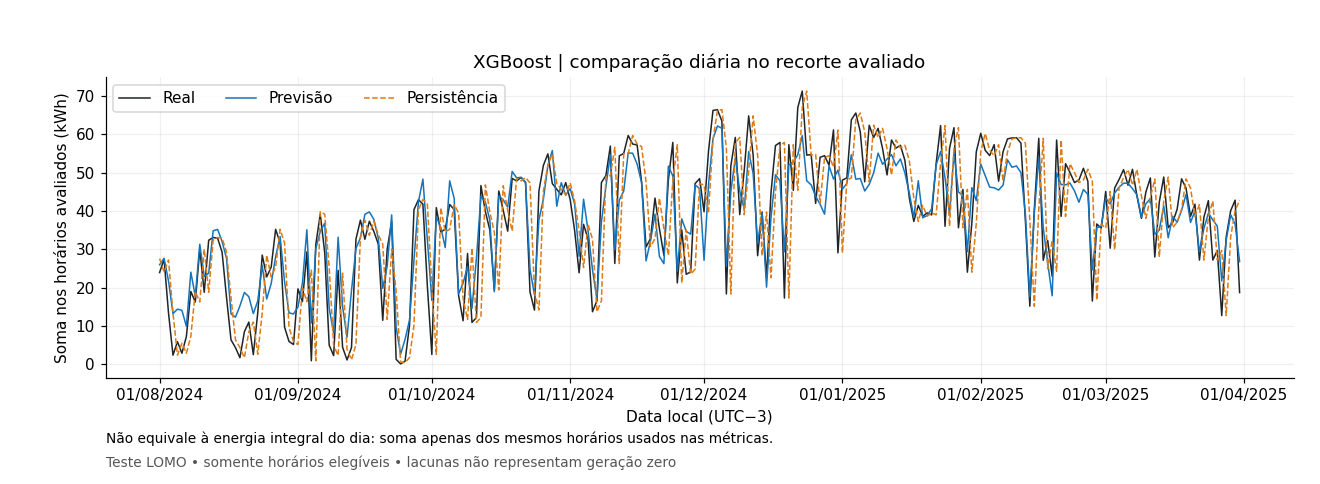

In [7]:
for modelo in ['KRR', 'MLP', 'SVR', 'XGBoost']:
    display(Image(filename=str(BASE/'graficos/resumos_diarios'/f'{modelo}_comparacao_diaria.png')))

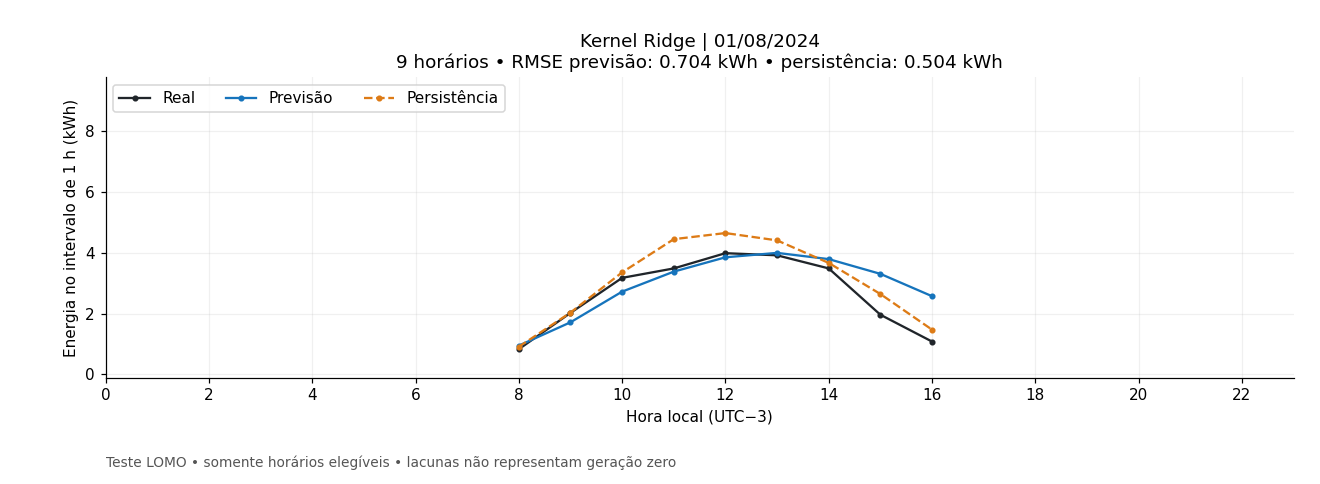

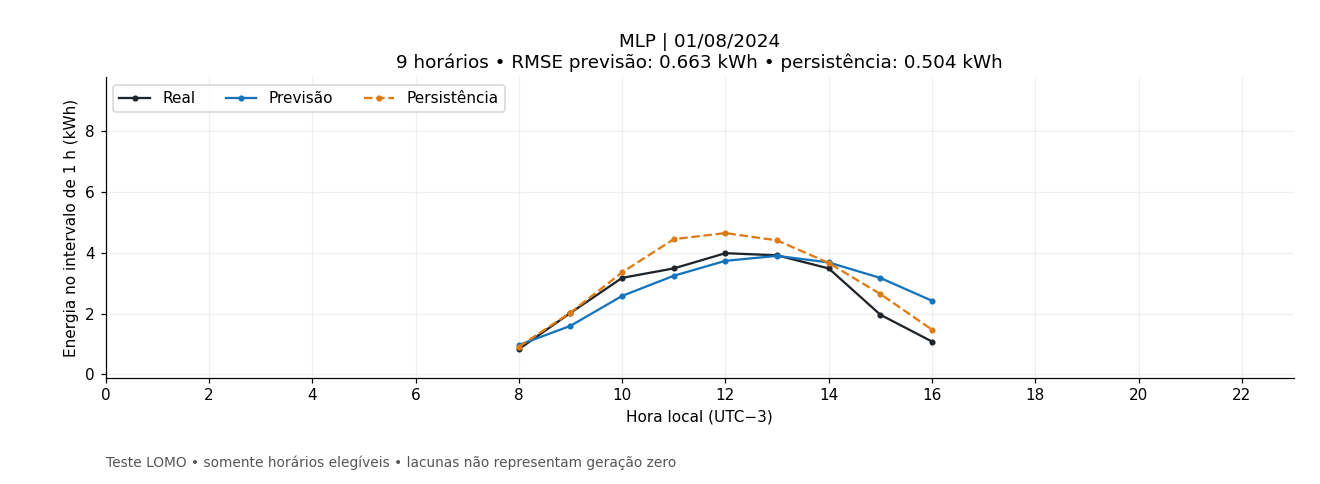

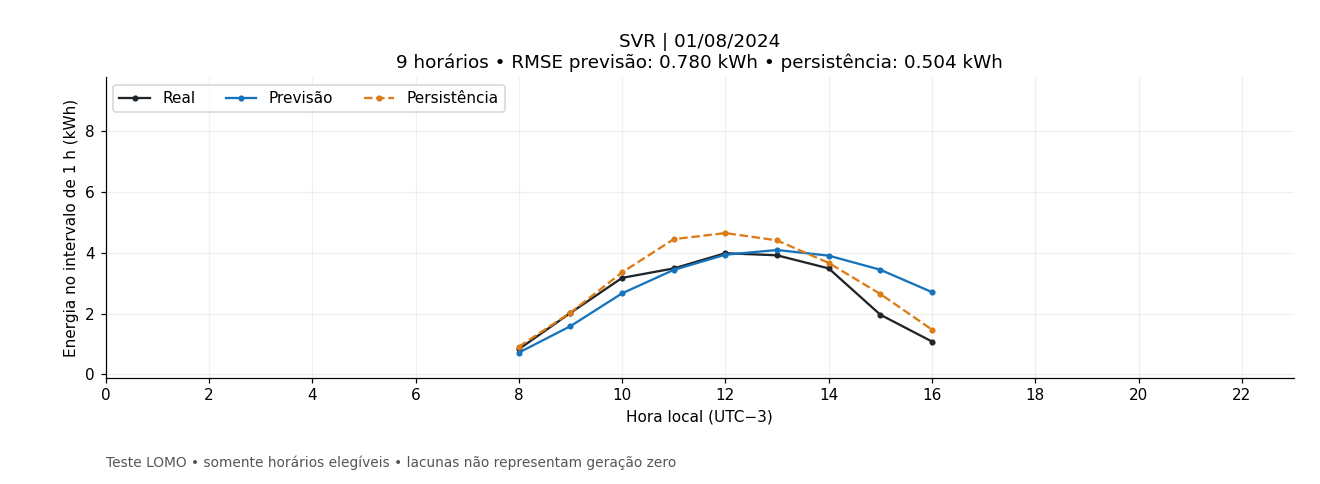

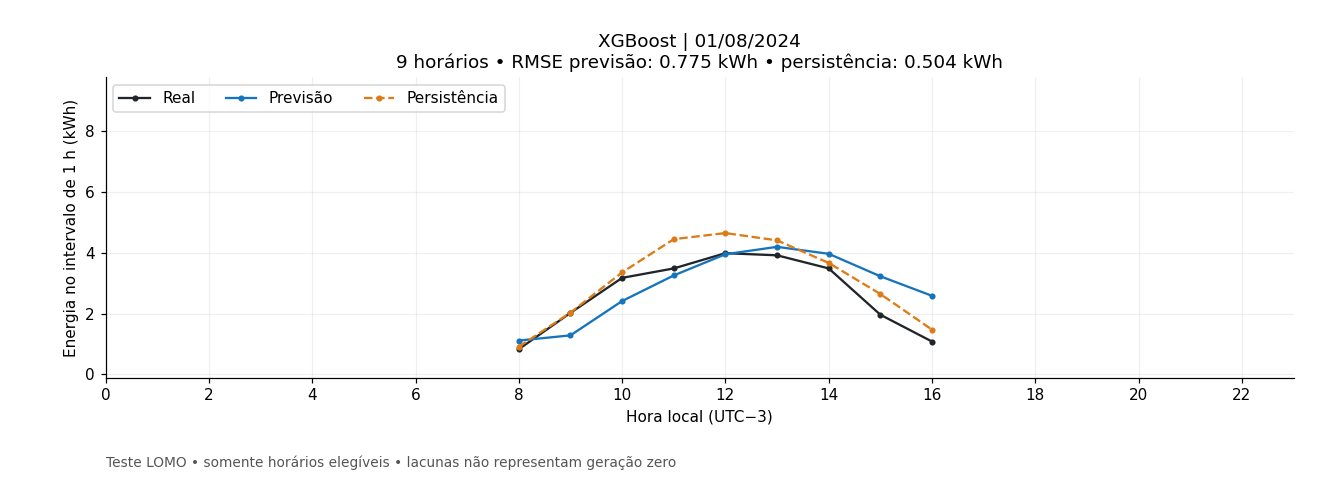

In [8]:
# Altere o dia para qualquer data entre 01/08/2024 e 31/03/2025.
DIA = '2024-08-01'
for MODELO in ['KRR', 'MLP', 'SVR', 'XGBoost']:
    display(Image(filename=str(BASE/'graficos/dias'/MODELO/f'{DIA}.png')))